# Modelling Script

In [55]:
#standard packages
import pandas as pd
import os 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import numpy as np
import seaborn as sns
from datetime import date

#modelling packages
import statsmodels.api as sm
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import shap
import optuna

#custom 
from actuals_vs_pred_graph import actuals_vs_pred_graph_func

In [56]:
#plan is to start simple and work up to more flexible models
path = os.path.abspath(os.path.join(os.getcwd(),"..",'final features','final_features.parquet'))
data = pd.read_parquet(path)

data

,date,state,net_electricity_gwh,mean_temp_c,elec_price_audmwh,temp_deviation,state_population,solar_exposure,trade_weighted_aud_index,average_max_temp,t,QLD,VIC
0,1990-01-01,NSW,NaN,NaN,NaN,NaN,5808103.0,20.7,59.4,25.577419,0,0,0
1,1990-01-01,VIC,NaN,NaN,NaN,NaN,4353666.0,26.0,59.4,26.632258,0,0,1
2,1990-01-01,QLD,NaN,NaN,NaN,NaN,2870728.0,25.8,59.4,31.322581,0,1,0
3,1990-02-01,NSW,NaN,NaN,NaN,NaN,5813127.0,19.2,59.0,25.100000,31,0,0
4,1990-02-01,VIC,NaN,NaN,NaN,NaN,4359107.0,20.6,59.0,24.785714,31,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,2025-12-01,VIC,4079.77,18.06,39.53,-0.850000,7110008.4,23.6,62.2,24.567742,13118,0,1
1295,2025-12-01,QLD,5901.81,24.90,61.69,0.457200,5707613.8,25.5,62.2,31.348387,13118,1,0
1296,2026-01-01,NSW,6778.23,22.91,81.53,-0.118077,8638403.0,23.0,64.5,27.809677,13149,0,0
1297,2026-01-01,VIC,4444.38,21.14,53.95,0.167273,7115931.7,24.8,64.5,29.087097,13149,0,1


[]

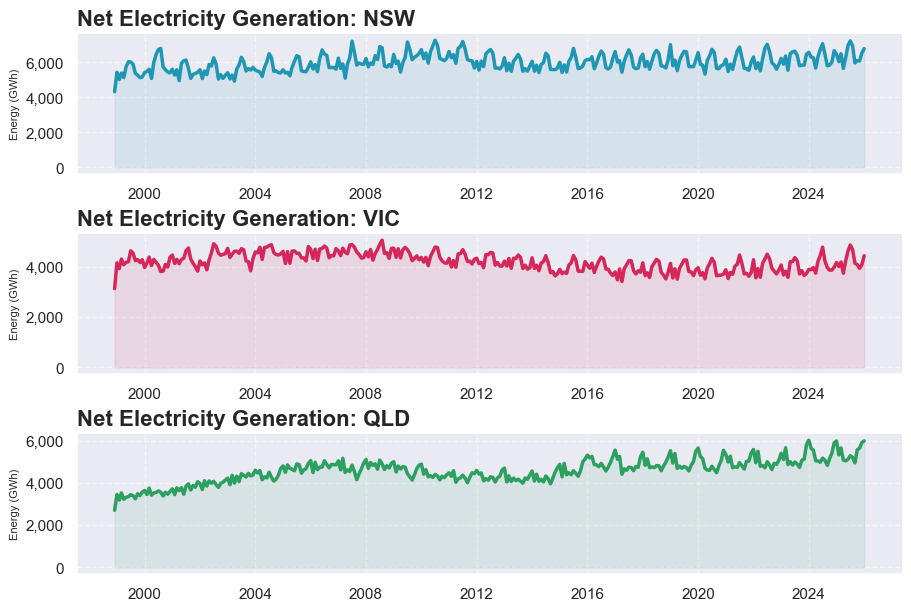

In [57]:
#plot series we are modelling

states = ['NSW','VIC','QLD']
colours = ["#1f96b4", "#d6275b", "#2ca060"]
df_plot = data[['date','state','net_electricity_gwh']]
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9, 6), constrained_layout=True)

for i, state in enumerate(states):
    ax = axes[i]
    state_data = df_plot[df_plot['state'] == state]
    ax.plot(state_data['date'], state_data['net_electricity_gwh'], 
            color=colours[i], linewidth=2.5, label=state)
    ax.fill_between(state_data['date'], state_data['net_electricity_gwh'], 
                    color=colours[i], alpha=0.1)

    ax.set_title(f'Net Electricity Generation: {state}', fontsize=16, fontweight='bold', loc='left')
    ax.set_ylabel(r'Energy (GWh)', fontsize=8)
    #ax.set_xlabel('Year', fontsize=8)
    fmt = '{x:,.12g}'
    tick = mtick.StrMethodFormatter(fmt)
    ax.xaxis.set_major_formatter(tick)
    ax.yaxis.set_major_formatter(tick) 

    ax.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.plot()

#seems to become more seasonal over time, particularly for QLD, perhaps this is solar's impact. 
#Interesting to see how efficiencies have essentially capped electricity generation over time, even with rising populations. 

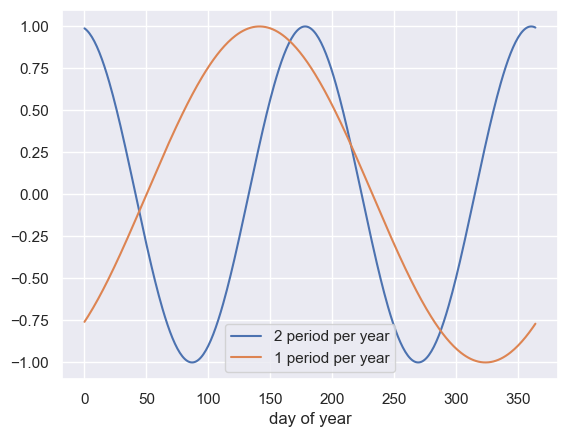

In [58]:
#simple bi annual trig function to capture repeating yearly seasonal trends, can improve this with an actual fourier fitting soon.
#get trig dataframe for a representative year ready.
trig_df = pd.DataFrame({'date' :pd.date_range(start='2000-01-01', periods=365, freq='D')}) #need to pick a year with a leap
trig_df['date'] = pd.to_datetime(trig_df['date'])
trig_df['day'] = trig_df['date'].dt.day
trig_df['month'] = trig_df['date'].dt.month

shift, shift2 = -50 , 50 # for manual fine tuning, essentially want either the peaks or the troughs in the Summer/Winter.
trig_df['trig_value_2season'] = np.sin(2 * np.pi * 2 / 365 * (trig_df.index - shift))
trig_df['trig_value_1season'] = np.sin(2 * np.pi * 1 / 365 * (trig_df.index - shift2))

plt.plot(trig_df['trig_value_2season'], label = '2 period per year')
plt.plot(trig_df['trig_value_1season'], label = '1 period per year')
plt.xlabel('day of year')
plt.legend()
plt.show()

trig_df.drop(columns='date', inplace=True)

#join onto dataset.
data['date'] = pd.to_datetime(data['date'])
data['day'] = data['date'].dt.day
data['month'] = data['date'].dt.month
data = data.merge(trig_df, on= ['day', 'month'])

In [59]:
#add absolute value of temp variation, to help the model get that deviations from seasonal trend are important too. 
data['abs_temp_deviation'] = data['temp_deviation'].abs()

#np.mean(data['average_max_temp'])
#add high temp indicator of 28+ degrees
data['high_temp_ind'] = (data['average_max_temp'] > 28).astype(int)

#add low temp indicator less than 16 degrees
data['low_temp_ind'] = (data['average_max_temp'] < 16).astype(int)

#add low temp indicator less than 16 degrees
data['year'] = pd.to_datetime(data['date']).dt.year
data['year_sqr'] = (data['year'] - min(data['year'] ))**2
data['year_cub'] = (data['year'] - min(data['year'] ))**3

In [60]:

#output data to csv
#data_folder = os.path.join(os.getcwd(), r'final features')
path = os.path.abspath(os.path.join(os.getcwd(),"..",'final features','final_features_engineered.csv'))
data.to_csv(path)
path = os.path.abspath(os.path.join(os.getcwd(),"..",'final features','final_features_engineered.parquet'))
data.to_parquet(path)

## 1. OLS Model

                             OLS Regression Results                            
Dep. Variable:     net_electricity_gwh   R-squared:                       0.870
Model:                             OLS   Adj. R-squared:                  0.868
Method:                  Least Squares   F-statistic:                     580.0
Date:                 Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                         12:50:47   Log-Likelihood:                -5126.0
No. Observations:                  708   AIC:                         1.028e+04
Df Residuals:                      696   BIC:                         1.033e+04
Df Model:                           11                                         
Covariance Type:                   HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

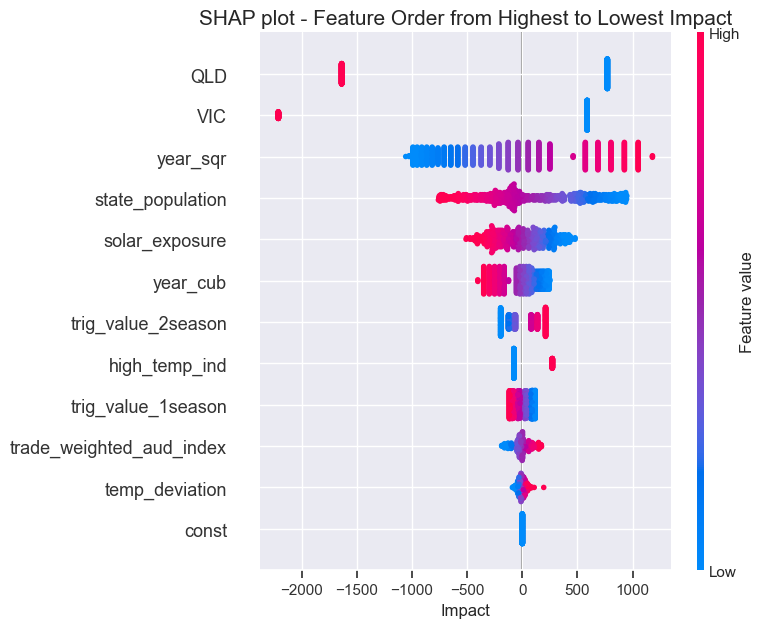

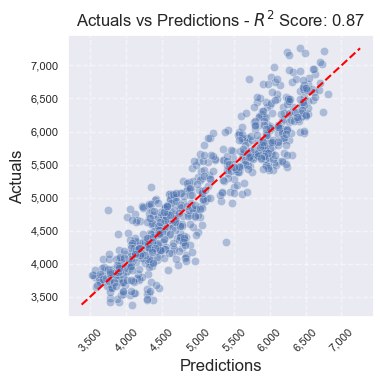

In [61]:
ols_data = data.dropna()
#select X 
x_list = [ #'mean_temp_c',
            #'elec_price_audmwh',
            'temp_deviation',
            'state_population',
            'solar_exposure',
            #'average_max_temp',
            #'t',
            'QLD',
            'VIC',
            'trig_value_2season',
            'trig_value_1season',
            'high_temp_ind',
            #'low_temp_ind',
            #'abs_temp_deviation',
            'trade_weighted_aud_index',
            'year_cub','year_sqr',#'year'
        ]

feature_list =['net_electricity_gwh'] + x_list


#select exogenous and endogenous variables
X = ols_data[x_list]
y = ols_data['net_electricity_gwh']

#std features
scaler = StandardScaler().set_output(transform="pandas")
X = scaler.fit_transform(X)

#add constant
X = sm.add_constant(X)

#fit and summarize
model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())
ols_data['predicted'] = model.predict(X)

#mean_temp, elec_price, abs_temp_deviation and average_max_temp are not significant looking linearly, can still explain 86% of the variance though.  0.868

#X.corr() #<-shows strong multicol between state poplation and state indicator, given that t is included it shouldnt hurt much removing it. Didnt need to StandardScaler helped.
#X.std() #<-no effective constant errors. 

explainer = shap.LinearExplainer((model.params.values, model.model.endog.mean()), X)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP plot - Feature Order from Highest to Lowest Impact', fontsize=15)
plt.xlabel('Impact', fontsize=12)
plt.show()


#compare graphically, the closer the points are to the 45 degree line the better fitting model
actuals_vs_pred_graph_func(y_actual = ols_data['net_electricity_gwh'], y_pred = ols_data['predicted'])

                             OLS Regression Results                            
Dep. Variable:     net_electricity_gwh   R-squared:                       0.870
Model:                             OLS   Adj. R-squared:                  0.868
Method:                  Least Squares   F-statistic:                     577.7
Date:                 Mon, 16 Feb 2026   Prob (F-statistic):               0.00
Time:                         12:50:49   Log-Likelihood:                -4863.3
No. Observations:                  672   AIC:                             9751.
Df Residuals:                      660   BIC:                             9805.
Df Model:                           11                                         
Covariance Type:                   HC3                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

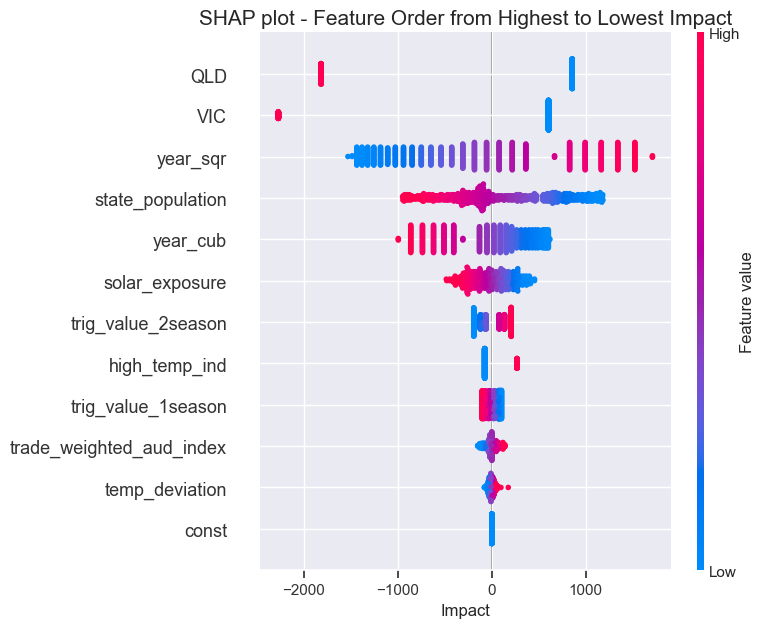

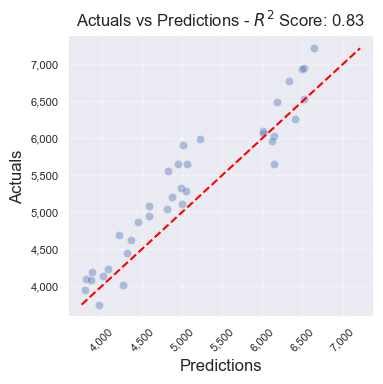

In [62]:
#test train split

ols_data = ols_data.set_index('date')
cutoff_date = ols_data.index.max() - pd.DateOffset(months=12)
train_data = ols_data[ols_data.index <= cutoff_date]
test_data = ols_data[ols_data.index > cutoff_date]

X_train = train_data[x_list]
y_train = train_data['net_electricity_gwh']

X_test = test_data[x_list]
y_test = test_data['net_electricity_gwh']

# scale data
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Do NOT refit here

# add constant 
X_train_scaled = sm.add_constant(X_train_scaled)
X_test_scaled = sm.add_constant(X_test_scaled)

#fit ols model
ols_model = sm.OLS(y_train, X_train_scaled).fit(cov_type='HC3')
print(ols_model.summary())

#generate preditions on train and test. 
pred_y_train = ols_model.predict(X_train_scaled)
pred_y_test = ols_model.predict(X_test_scaled)


#mean_temp, elec_price, abs_temp_deviation and average_max_temp are not significant looking linearly, can still explain 86% of the variance though.  0.868

#X.corr() #<-shows strong multicol between state poplation and state indicator, given that t is included it shouldnt hurt much removing it. Didnt need to StandardScaler helped.
#X.std() #<-no effective constant errors. 

explainer = shap.LinearExplainer((ols_model.params.values, ols_model.model.endog.mean()), X)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values, X, show=False)
plt.title('SHAP plot - Feature Order from Highest to Lowest Impact', fontsize=15)
plt.xlabel('Impact', fontsize=12)
plt.show()


#compare graphically, the closer the points are to the 45 degree line the better fitting model
actuals_vs_pred_graph_func(y_actual = y_test, y_pred = pred_y_test)

## 2. XGBoost Model (higher fitting)

In [63]:
xgboost_data = data

#remove nulls in exogenous.
xgboost_data = xgboost_data.loc[xgboost_data['net_electricity_gwh'].notnull()].copy()

#select X 
x_list_xgb = [ #'mean_temp_c',
            #'elec_price_audmwh',
            #'temp_deviation', #<- potential leakage
            'state_population',
            'solar_exposure',
            'average_max_temp',
            't',
            'QLD',
            'VIC',
            'trig_value_2season',
            'trig_value_1season',
            #'high_temp_ind',
            #'low_temp_ind',
            #'abs_temp_deviation', #<- potential leakage
            'trade_weighted_aud_index',
            'year_cub','year_sqr',#'year'
        ]

feature_list_xgb =['net_electricity_gwh'] + x_list_xgb


#select exogenous and endogenous variables
X = xgboost_data[x_list_xgb]
y = xgboost_data['net_electricity_gwh']


#std features
scaler = StandardScaler().set_output(transform="pandas")
X = scaler.fit_transform(X)

#add constant
X = sm.add_constant(X)

#xgboost_data


In [64]:
# ##settings selection using optuna
# def objective(trial):
#     #ranges to search through
#     param = {
#         "n_estimators": trial.suggest_int("n_estimators", 500, 1000),
#         "max_depth": trial.suggest_int("max_depth", 2, 3), ###force simpler models
#         "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 0.9),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 100, log=True), 
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
#     }

#     tss = TimeSeriesSplit(n_splits=5)
#     scores = []
    
#     for train_idx, val_idx in tss.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

#         model = xgb.XGBRegressor(**param, random_state=42)
#         model.fit(X_tr, y_tr)
        
#         preds = model.predict(X_val)
#         rmse = np.sqrt(mean_squared_error(y_val, preds))
#         scores.append(rmse)
    
#     return np.mean(scores)

# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=35) 

# print("Best Parameters:", study.best_params)

# #best 409.1169 rmse
# #{'n_estimators': 737, 'max_depth': 2, 'learning_rate': 0.0999567027266253, 'subsample': 0.8204136910388644, 'colsample_bytree': 0.778979555359994, 'reg_lambda': 2.0720312042041003, 'min_child_weight': 4}

In [65]:

#Run model with best param
opt_params = study.best_params if 'study.best_params' in locals() else {'n_estimators': 737, 'max_depth': 2, 'learning_rate': 0.0999567027266253, 'subsample': 0.8204136910388644, 'colsample_bytree': 0.778979555359994, 'reg_lambda': 2.0720312042041003, 'min_child_weight': 4}
#opt_params = study.best_params
splits = 3
tss = TimeSeriesSplit(n_splits=splits)

for train_idx, val_idx in tss.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # select xgboost para
    model = xgb.XGBRegressor(**opt_params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

Estimated Training R2 Score: 0.99
Estimated Validation R2 Score: 0.85


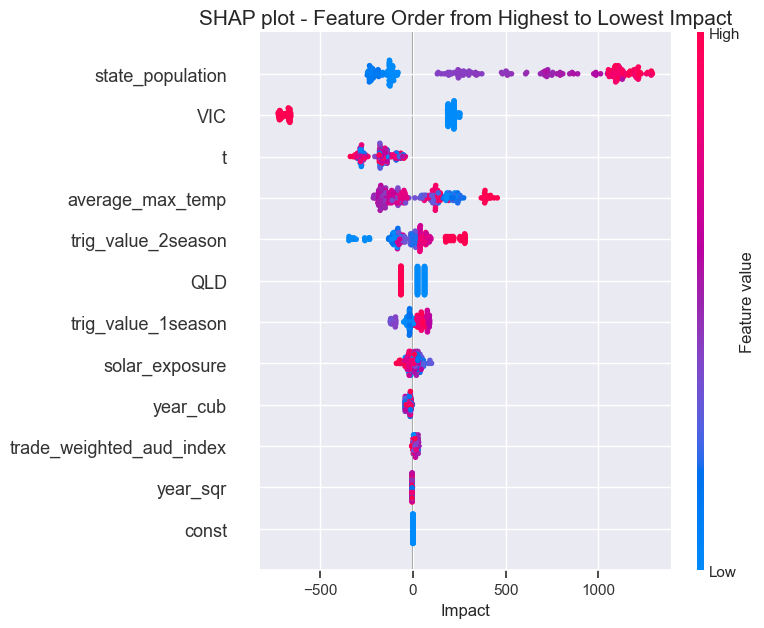

actual vs pred


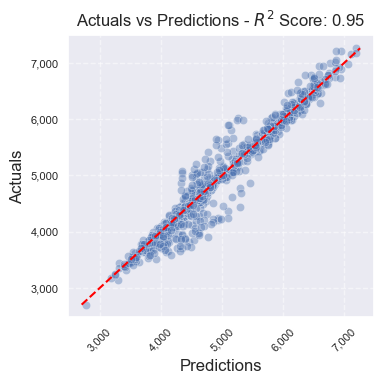

validation set actual vs pred


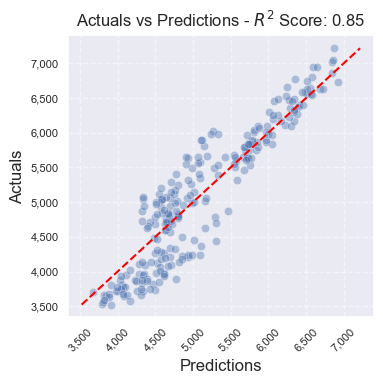

In [66]:
#evaluation
preds = model.predict(X_train)
r2_tra = r2_score(y_train, preds)
print(f"Estimated Training "+f'R2 Score: {r2_tra:.2f}')

preds = model.predict(X_val)
r2_val = r2_score(y_val, preds)
print(f"Estimated Validation "+f'R2 Score: {r2_val:.2f}')

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values, X_val, show=False)
plt.title('SHAP plot - Feature Order from Highest to Lowest Impact', fontsize=15)
plt.xlabel('Impact', fontsize=12)
plt.show()


#compare graphically, the closer the points are to the 45 degree line the better fitting model

print('actual vs pred')
preds = model.predict(X)
actuals_vs_pred_graph_func(y_actual = y, y_pred = preds)

print('validation set actual vs pred')
preds = model.predict(X_val)
actuals_vs_pred_graph_func(y_actual = y_val, y_pred = preds)

## 3. Produce Forecasts

In [67]:
# redo analysis together
path = os.path.abspath(os.path.join(os.getcwd(),"..",'final features','final_features_engineered.parquet'))
df = pd.read_parquet(path)


#shared feature set
x_list = [
    'state_population', 
    #'solar_exposure',
    #'trade_weighted_aud_index', 
    #'average_max_temp',
      't', 'QLD', 'VIC', 
      'trig_value_2season', 'trig_value_1season', 
      #'high_temp_ind', 'low_temp_ind', 
    #'mean_temp_c', 'elec_price_audmwh'
    'year_cub','year_sqr'
]
y_list = 'net_electricity_gwh'
all_vars = x_list + [y_list]

#drop nulls
model_data = df.dropna(subset=all_vars).copy()
model_data['date'] = pd.to_datetime(model_data['date'])
model_data = model_data.sort_values(['date', 'state'])

#test train splits - months
months = 12
unique_dates = sorted(model_data['date'].unique())
test_dates = unique_dates[-months:]
train_dates = unique_dates[:-months]

train_data = model_data[model_data['date'].isin(train_dates)]
test_data = model_data[model_data['date'].isin(test_dates)]

X_train = train_data[x_list]
y_train = train_data[y_list]
X_test = test_data[x_list]
y_test = test_data[y_list]



Model - Testing Data - Ordinary Least Squares Regression


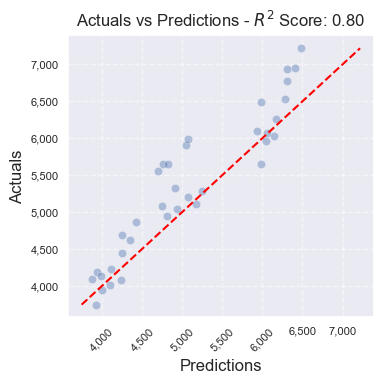

Model - Testing Data - XGBoost Gradient Boosting Tree Model


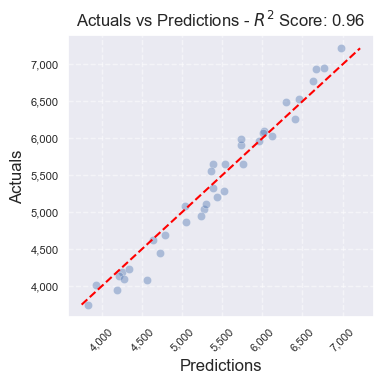

In [68]:

#run xgb model with best param
opt_params = study.best_params if 'study.best_params' in locals() else {'n_estimators': 737, 'max_depth': 2, 'learning_rate': 0.0999567027266253, 'subsample': 0.8204136910388644, 'colsample_bytree': 0.778979555359994, 'reg_lambda': 2.0720312042041003, 'min_child_weight': 4}

# fit models
ols_model = sm.OLS(y_train, sm.add_constant(X_train)).fit()
xgb_model = xgb.XGBRegressor(**opt_params)
xgb_model.fit(X_train, y_train,
            verbose=False)

ols_test_pred = ols_model.predict(sm.add_constant(X_test))
xgb_test_pred = xgb_model.predict(X_test)

# testing confirmation of fit. While the XGBmodel is good more accurate, a two stage model with a OLS core and XGBoost model predicting residuals would probably be more effective because XGB cannot extrapolate overall trends well
print('Model - Testing Data - Ordinary Least Squares Regression')
actuals_vs_pred_graph_func(y_actual = y_test, y_pred = ols_test_pred)

print('Model - Testing Data - XGBoost Gradient Boosting Tree Model')
actuals_vs_pred_graph_func(y_actual = y_test, y_pred = xgb_test_pred)


# recreate original df with predictions.
df_full = df.copy()
predict_mask = df_full[x_list].notnull().all(axis=1)
df_full.loc[predict_mask, 'ols_prediction'] = ols_model.predict(sm.add_constant(df_full.loc[predict_mask, x_list]))
df_full.loc[predict_mask, 'xgb_prediction'] = xgb_model.predict(df_full.loc[predict_mask, x_list])

##get indicators for forecasting 
min_test_date = min(test_dates )
df_full['test_indicator'] = np.where(df_full['date'] < min_test_date, 'train', 'test')

In [69]:
#cut off extra rows
list_null_dates = df_full['date'].loc[df_full['net_electricity_gwh'].isna()]
list_null_dates = list_null_dates.unique().max()

df_full = df_full.loc[ df_full['date'] > list_null_dates].copy()

Model - XGBoost Gradient Boosting Tree Model


[]

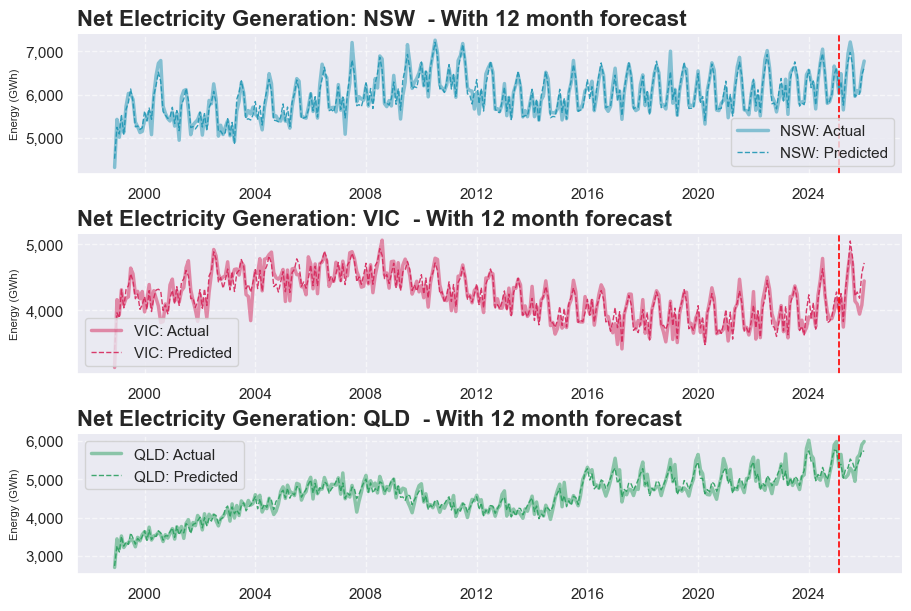

In [70]:
#plot modelling
print('Model - XGBoost Gradient Boosting Tree Model')
states = ['NSW','VIC','QLD']
colours = ["#1f96b4", "#d6275b", "#2ca060"]
df_plot = df_full[['date','state','net_electricity_gwh','xgb_prediction','ols_prediction']]
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(9, 6), constrained_layout=True)

for i, state in enumerate(states):
    ax = axes[i]
    state_data = df_plot[df_plot['state'] == state]
    ax.plot(state_data['date'], state_data['net_electricity_gwh'], 
            color=colours[i], linewidth=2.5, label=state + ': Actual', alpha = 0.5)
    ax.plot(state_data['date'], state_data['xgb_prediction'], linestyle='--',#'ols_prediction'], linestyle='--',#
            color=colours[i], linewidth=1, label=state + ': Predicted', alpha = 0.9)
    # ax.fill_between(state_data['date'], state_data['net_electricity_gwh'], 
    #                 color=colours[i], alpha=0.1)

    ax.set_title(f'Net Electricity Generation: {state}  - With 12 month forecast', fontsize=16, fontweight='bold', loc='left')
    ax.set_ylabel(r'Energy (GWh)', fontsize=8)
    #ax.set_xlabel('Year', fontsize=8)
    fmt = '{x:,.12g}'
    tick = mtick.StrMethodFormatter(fmt)
    ax.xaxis.set_major_formatter(tick)
    ax.yaxis.set_major_formatter(tick) 
        #add in estimation from 
    ax.axvline(x=min(test_dates), color='red', linestyle='--', linewidth=1.2)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.plot()


In [71]:

#output data to parquet
data_folder = os.path.join(os.getcwd())
file_name = r'model_output.parquet'

path = os.path.join(data_folder,file_name)
df_full.to_parquet(path)

file_name = r'model_output.xlsx'
path = os.path.join(data_folder,file_name)

df_full.to_excel(path, index=False, sheet_name='Sheet1')

In [72]:
df_full

,date,state,net_electricity_gwh,mean_temp_c,elec_price_audmwh,temp_deviation,state_population,solar_exposure,trade_weighted_aud_index,average_max_temp,...,trig_value_1season,abs_temp_deviation,high_temp_ind,low_temp_ind,year,year_sqr,year_cub,ols_prediction,xgb_prediction,test_indicator
321,1998-12-01,NSW,4321.52,21.94,20.16,0.228462,6338790.0,25.0,53.0,25.990323,...,-0.981306,0.228462,0,0,1998,64,512,5286.901126,4522.949219,train
322,1998-12-01,VIC,3135.09,NaN,20.57,NaN,4629345.0,24.7,53.0,24.664516,...,-0.981306,NaN,0,0,1998,64,512,3703.203011,3400.520508,train
323,1998-12-01,QLD,2705.21,NaN,33.17,NaN,3427505.0,24.1,53.0,30.883871,...,-0.981306,NaN,1,0,1998,64,512,4021.045064,2745.150635,train
324,1999-01-01,NSW,5431.08,23.42,NaN,0.391923,6346044.0,24.9,54.8,27.480645,...,-0.758306,0.391923,0,0,1999,81,729,5294.148023,5248.467285,train
325,1999-01-01,VIC,4160.67,NaN,NaN,NaN,4634614.0,23.7,54.8,27.041935,...,-0.758306,NaN,0,0,1999,81,729,3715.423785,3962.181396,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1294,2025-12-01,VIC,4079.77,18.06,39.53,-0.850000,7110008.4,23.6,62.2,24.567742,...,-0.981306,0.850000,0,0,2025,1225,42875,4233.842422,4564.393555,test
1295,2025-12-01,QLD,5901.81,24.90,61.69,0.457200,5707613.8,25.5,62.2,31.348387,...,-0.981306,0.457200,1,0,2025,1225,42875,5054.220405,5736.786133,test
1296,2026-01-01,NSW,6778.23,22.91,81.53,-0.118077,8638403.0,23.0,64.5,27.809677,...,-0.758306,0.118077,0,0,2026,1296,46656,6306.359847,6628.438965,test
1297,2026-01-01,VIC,4444.38,21.14,53.95,0.167273,7115931.7,24.8,64.5,29.087097,...,-0.758306,0.167273,1,0,2026,1296,46656,4254.155886,4717.636719,test
